# Dark Magnet

Build a tool that allows you to click a pixel of an image and it finds the darkest point near to it!

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import DLCsupport as dlcs
def find_darkest_pixel(img, row, col, window_size=4):
    """
    Find the darkest pixel in a window around the specified pixel.

    Parameters
    ----------
    img : np.ndarray
        Grayscale image (2D array).
    row : int
        Row index of selected pixel.
    col : int
        Column index of selected pixel.
    window_size : int
        Size of square neighborhood (default 4).

    Returns
    -------
    darkest_row : int
    darkest_col : int
    darkest_value : int or float
    """
    
    half = window_size // 2

    # Define window bounds and clip to image edges
    r0 = max(0, int(row) - half)
    r1 = min(img.shape[0], r0 + window_size)

    c0 = max(0, int(col) - half)
    c1 = min(img.shape[1], c0 + window_size)

    # Extract neighborhood
    window = img[r0:r1, c0:c1]

    # Find darkest pixel
    local_idx = np.argmin(window)
    local_row, local_col = np.unravel_index(local_idx, window.shape)

    darkest_row = r0 + local_row
    darkest_col = c0 + local_col
    darkest_value = img[darkest_row, darkest_col]

    # plt.figure(figsize=(8, 8))
    # plt.imshow(img, cmap = 'grey')
    # plt.scatter(
    #     darkest_col,
    #     darkest_row,
    #     c='white',
    #     s=40,
    #     edgecolors='black'
    # )
    # plt.title(f"Darkest pixel: {darkest_row, darkest_col}")
    # plt.show()

    return [darkest_row, darkest_col]

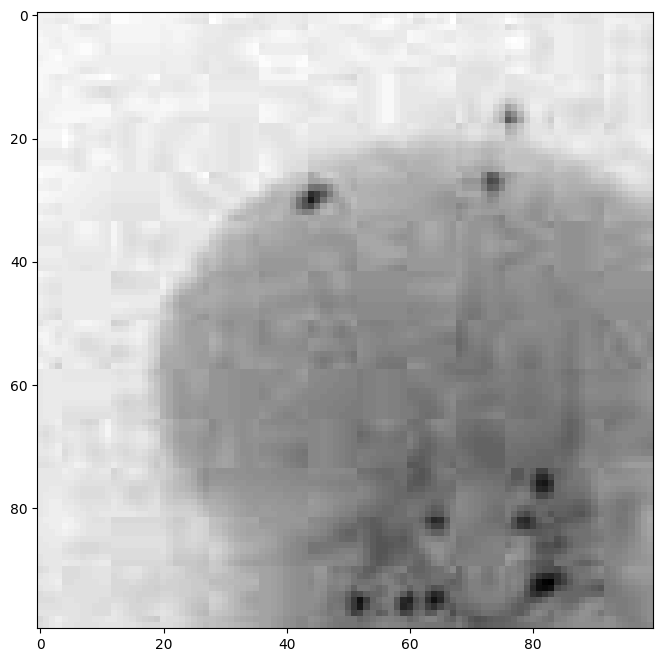

looking for darkest pixel around row 95 and col 79 with window size 6


[93, 81]

In [3]:
img = plt.imread(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DinoSamplesData\TrainT17_EvalT15\Cam1\Cam1_Img002466.jpg")
img_croped = img[150:250, 300:400]
plt.figure(figsize=(8, 8))
plt.imshow(img_croped, cmap = 'grey')
plt.show()
r = 95
c = 79
window = 6
print(f"looking for darkest pixel around row {r} and col {c} with window size {window}")
find_darkest_pixel(img_croped, row = r, col = c, window_size=window)

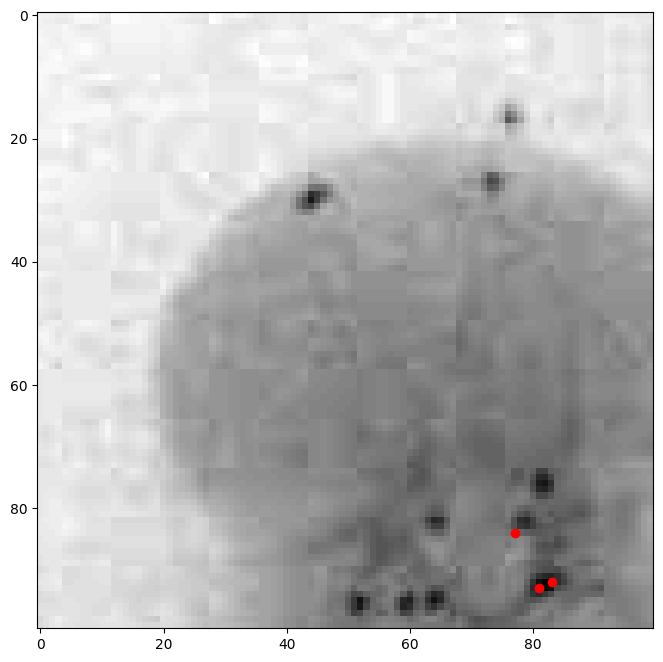

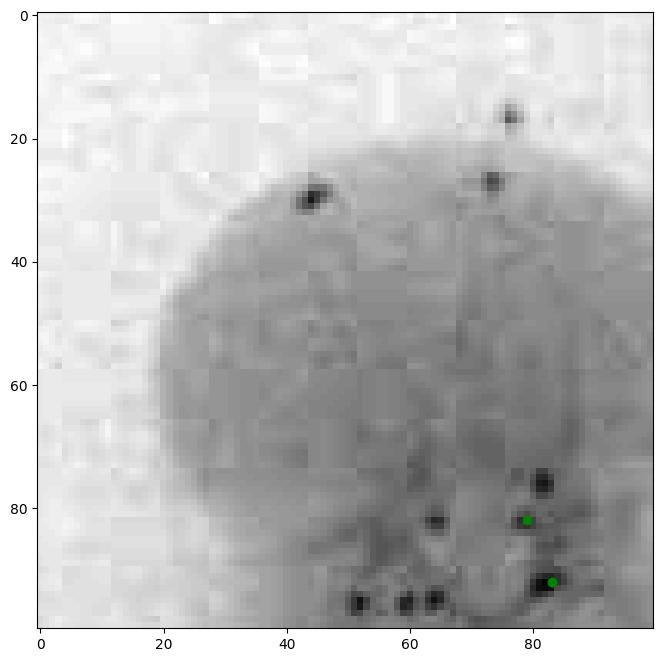

In [4]:
plt.figure(figsize=(8, 8))
plt.imshow(img_croped, cmap = 'grey')
preds = {"BR1":[93, 81], "BR2":[92, 83], "Max1": [84, 77]}
coords = np.array(list(preds.values()))
plt.scatter(coords[:, 1], coords[:, 0], c='red')
plt.show()
preds.update({
    key: find_darkest_pixel(
        img_croped,
        row=values[0],
        col=values[1],
        window_size=window
    )
    for key, values in preds.items()
})

plt.figure(figsize=(8, 8))
plt.imshow(img_croped, cmap = 'grey')

coords = np.array(list(preds.values()))
plt.scatter(coords[:, 1], coords[:, 0], c='green')
plt.show()

In [15]:
occupied = set()

def find_darkest_pixel(img, row, col, window_size=5):

    half = window_size // 2

    r0 = max(0, int(row) - half)
    r1 = min(img.shape[0], int(row) + half + 1)

    c0 = max(0, int(col) - half)
    c1 = min(img.shape[1], int(col) + half + 1)

    window = img[r0:r1, c0:c1]

    flat = np.argsort(window, axis=None)

    for idx in flat:
        lr, lc = np.unravel_index(idx, window.shape)
        rr, cc = r0 + lr, c0 + lc

        if (rr, cc) not in occupied:
            occupied.add((rr, cc))
            return rr, cc

    return r0, c0

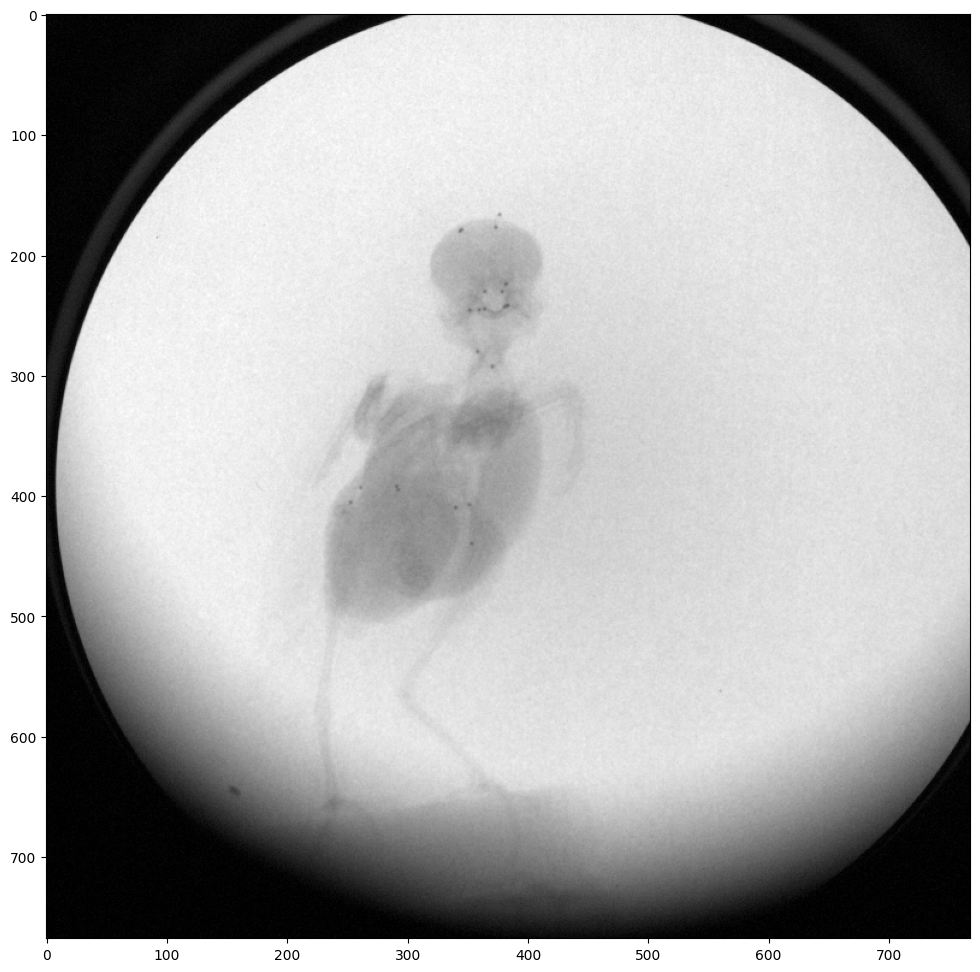

,frame_id,bodypart,camera,x_true,y_true
0,1,Cranium_Left_Anterior,cam1,373.809209,175.908624
100,1,Cranium_Left_Middle,cam1,376.579220,165.826861
200,1,Cranium_Right_Middle,cam1,344.314883,178.370694
300,1,Cranium_Right_Posterior,cam1,345.032394,179.453399
400,1,Beak_Mandible_Left_Posterior,cam1,382.453326,223.815459
500,1,Beak_Mandibile_Left_Anterior,cam1,379.293548,230.163533
600,1,Beak_Mandible_Right_Anterior,cam1,364.661935,229.964623
700,1,Beak_Maxilla_Right_Anterior,cam1,363.838480,243.545939
800,1,Beak_Maxilla_Right_Posterior,cam1,359.002493,244.749833
900,1,Beak_Maxilla_Left_Anterior,cam1,381.736479,241.854550


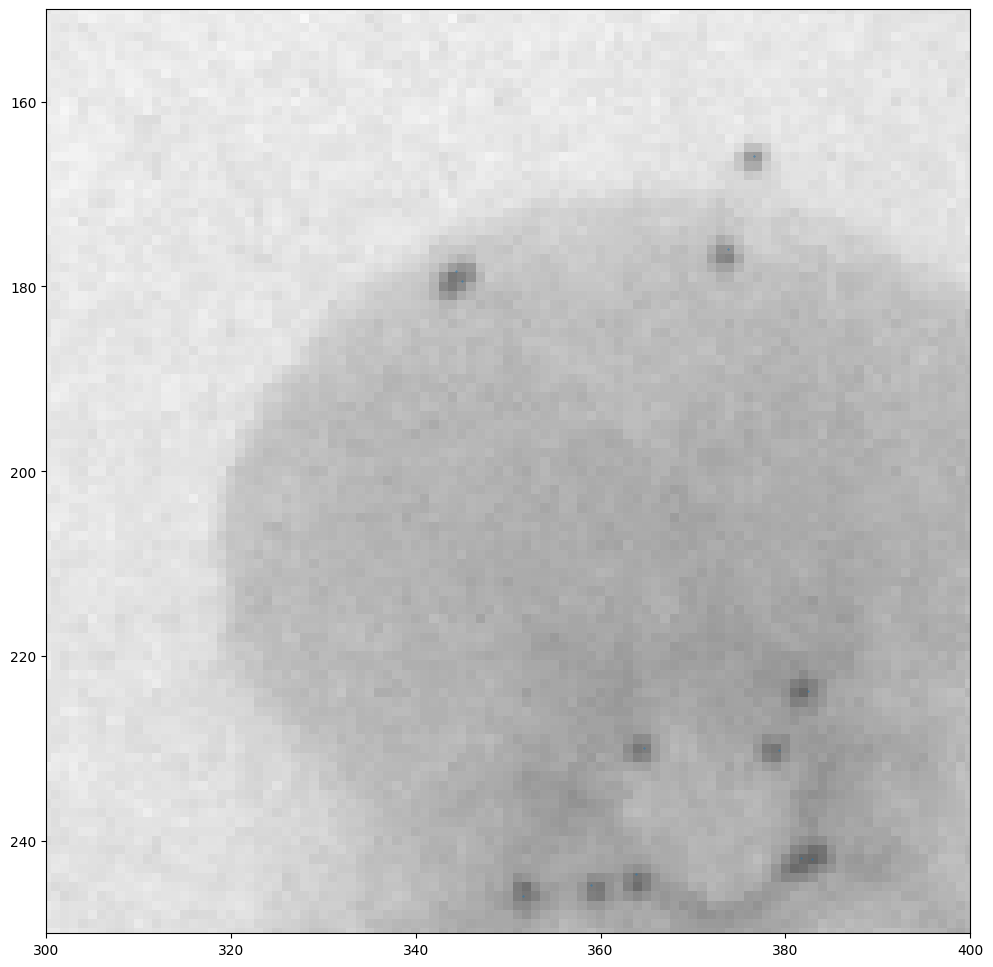

,frame_id,bodypart,camera,x_true,y_true,x_new,y_new
0,1,Cranium_Left_Anterior,cam1,373.809209,175.908624,374,177
100,1,Cranium_Left_Middle,cam1,376.579220,165.826861,377,166
200,1,Cranium_Right_Middle,cam1,344.314883,178.370694,344,179
300,1,Cranium_Right_Posterior,cam1,345.032394,179.453399,344,180
400,1,Beak_Mandible_Left_Posterior,cam1,382.453326,223.815459,382,224
500,1,Beak_Mandibile_Left_Anterior,cam1,379.293548,230.163533,379,230
600,1,Beak_Mandible_Right_Anterior,cam1,364.661935,229.964623,364,230
700,1,Beak_Maxilla_Right_Anterior,cam1,363.838480,243.545939,364,245
800,1,Beak_Maxilla_Right_Posterior,cam1,359.002493,244.749833,360,245
900,1,Beak_Maxilla_Left_Anterior,cam1,381.736479,241.854550,383,242


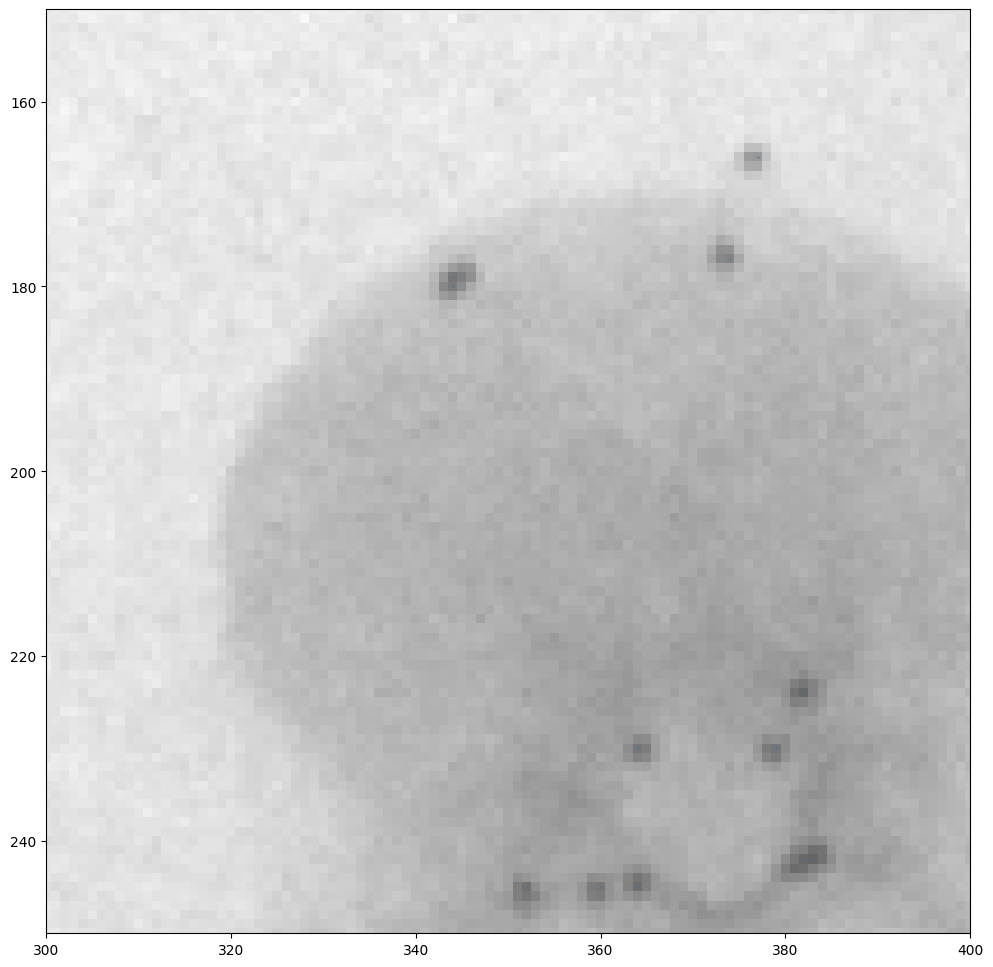

In [16]:
image = plt.imread(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DisplacementSamplesData\TrainT17_EvalT15\_build\Displacement_s125_TrainT17_EvalT15_F400_S42\clean_trial\Cam1\Cam1_Img002450.jpg")
data = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DisplacementSamplesData\TrainT17_EvalT15\_build\Displacement_s125_TrainT17_EvalT15_F400_S42\clean_trial\Displacement_s125_TrainT17_EvalT15_F400_S42-2Dpoints.csv"
data_long = dlcs.truth_csv_to_long(data)
data_long = data_long[(data_long['camera'] == "cam1") & (data_long['frame_id'] == 1)]
plt.figure(figsize=(12, 12))
plt.imshow(image, cmap= 'grey')
plt.show()

# img_croped = image[150:250, 300:400]

# plt.figure(figsize=(12, 12))
# plt.imshow(img_croped, cmap= 'grey')
# plt.show()

display(data_long)

plt.figure(figsize=(12, 12))
plt.imshow(image, cmap= 'grey')
plt.scatter(data_long['x_true'], data_long['y_true'], s = .11)
plt.ylim(250, 150)
plt.xlim(300, 400)
plt.show()

new_x = []
new_y = []
# for index, row in data_long.iterrows():
#     x = row['x_true']
#     y = row['y_true']
#     updated_point = find_darkest_pixel(image, x, y, window_size=4)
#     new_x.append(updated_point[0])
#     new_y.append(updated_point[1])

new_x = []
new_y = []

for _, row in data_long.iterrows():

    x = int(row['x_true'])
    y = int(row['y_true'])

    new_y_, new_x_ = find_darkest_pixel(image, y, x, window_size=4)

    new_x.append(new_x_)
    new_y.append(new_y_)

data_long_magneted = data_long.copy()
data_long_magneted['x_new'] = new_x
data_long_magneted['y_new'] = new_y
display(data_long_magneted)
plt.figure(figsize=(12, 12))
plt.imshow(image, cmap= 'grey')
plt.scatter(data_long_magneted['x_new'], data_long_magneted['y_new'], s = .11)
plt.ylim(250, 150)
plt.xlim(300, 400)
plt.show()

In [59]:
# Alternative
def find_darkest_region_center(img, row, col, search_radius=4):
    """
    Find the pixel within a neighborhood whose surrounding 3x3
    box has the lowest intensity sum.

    Parameters
    ----------
    img : np.ndarray
        Grayscale image.
    row : int
        Center row.
    col : int
        Center column.
    search_radius : int
        Search radius around (row, col).

    Returns
    -------
    [best_row, best_col]
        Location whose 3x3 neighborhood has minimum sum.
    """

    row = int(row)
    col = int(col)

    # Search bounds
    r0 = max(0, row - search_radius)
    r1 = min(img.shape[0], row + search_radius + 1)

    c0 = max(0, col - search_radius)
    c1 = min(img.shape[1], col + search_radius + 1)

    best_sum = np.inf
    best_row = row
    best_col = col

    for r in range(r0, r1):
        for c in range(c0, c1):

            # 3x3 box around candidate point
            rr0 = max(0, r - 1)
            rr1 = min(img.shape[0], r + 2)

            cc0 = max(0, c - 1)
            cc1 = min(img.shape[1], c + 2)

            local_sum = img[rr0:rr1, cc0:cc1].sum()

            if local_sum < best_sum:
                best_sum = local_sum
                best_row = r
                best_col = c

    return [best_row, best_col]

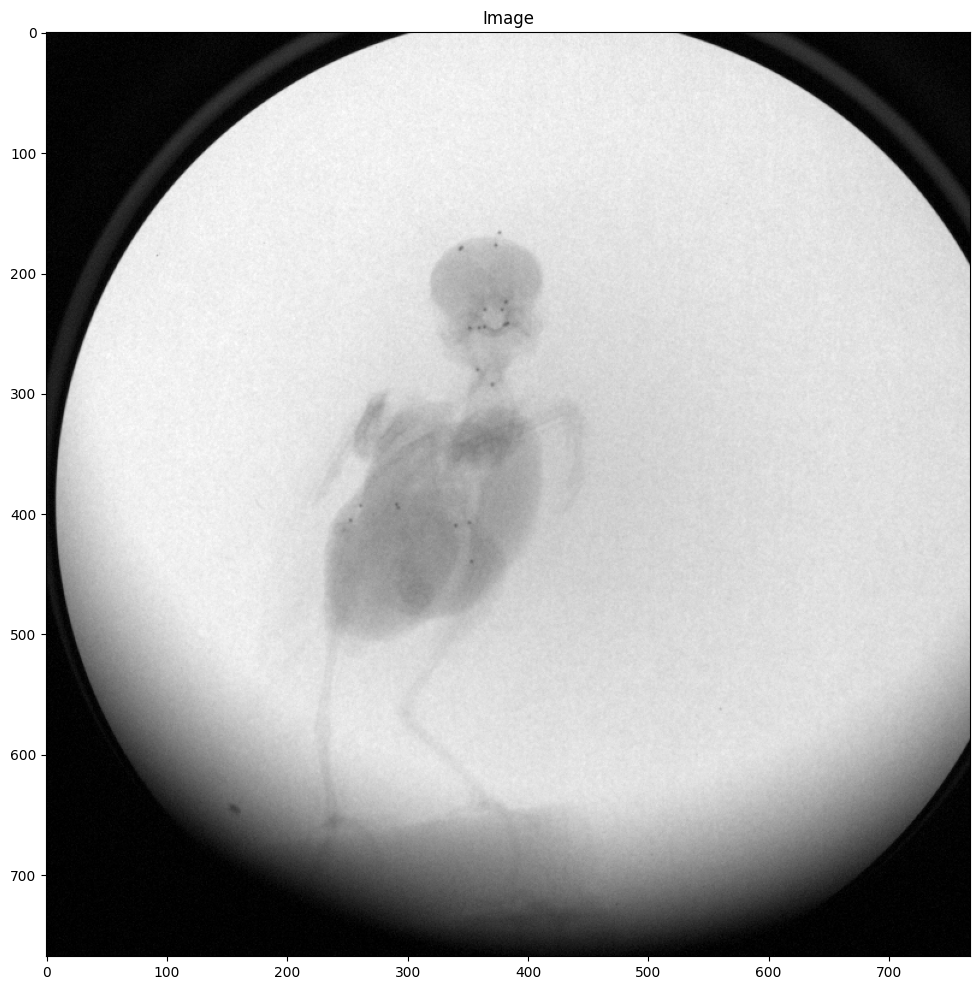

,frame_id,bodypart,camera,x_true,y_true
0,1,Cranium_Left_Anterior,cam1,373.809209,175.908624
100,1,Cranium_Left_Middle,cam1,376.579220,165.826861
200,1,Cranium_Right_Middle,cam1,344.314883,178.370694
300,1,Cranium_Right_Posterior,cam1,345.032394,179.453399
400,1,Beak_Mandible_Left_Posterior,cam1,382.453326,223.815459
500,1,Beak_Mandibile_Left_Anterior,cam1,379.293548,230.163533
600,1,Beak_Mandible_Right_Anterior,cam1,364.661935,229.964623
700,1,Beak_Maxilla_Right_Anterior,cam1,363.838480,243.545939
800,1,Beak_Maxilla_Right_Posterior,cam1,359.002493,244.749833
900,1,Beak_Maxilla_Left_Anterior,cam1,381.736479,241.854550


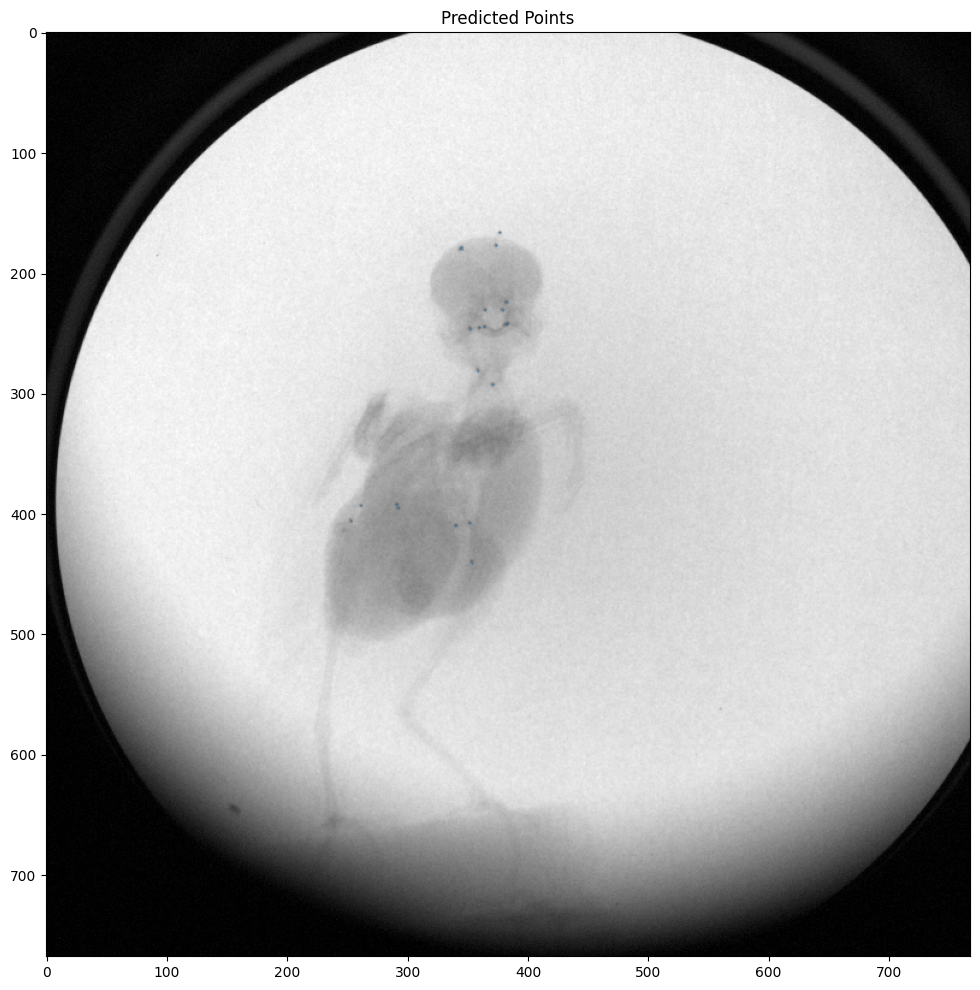

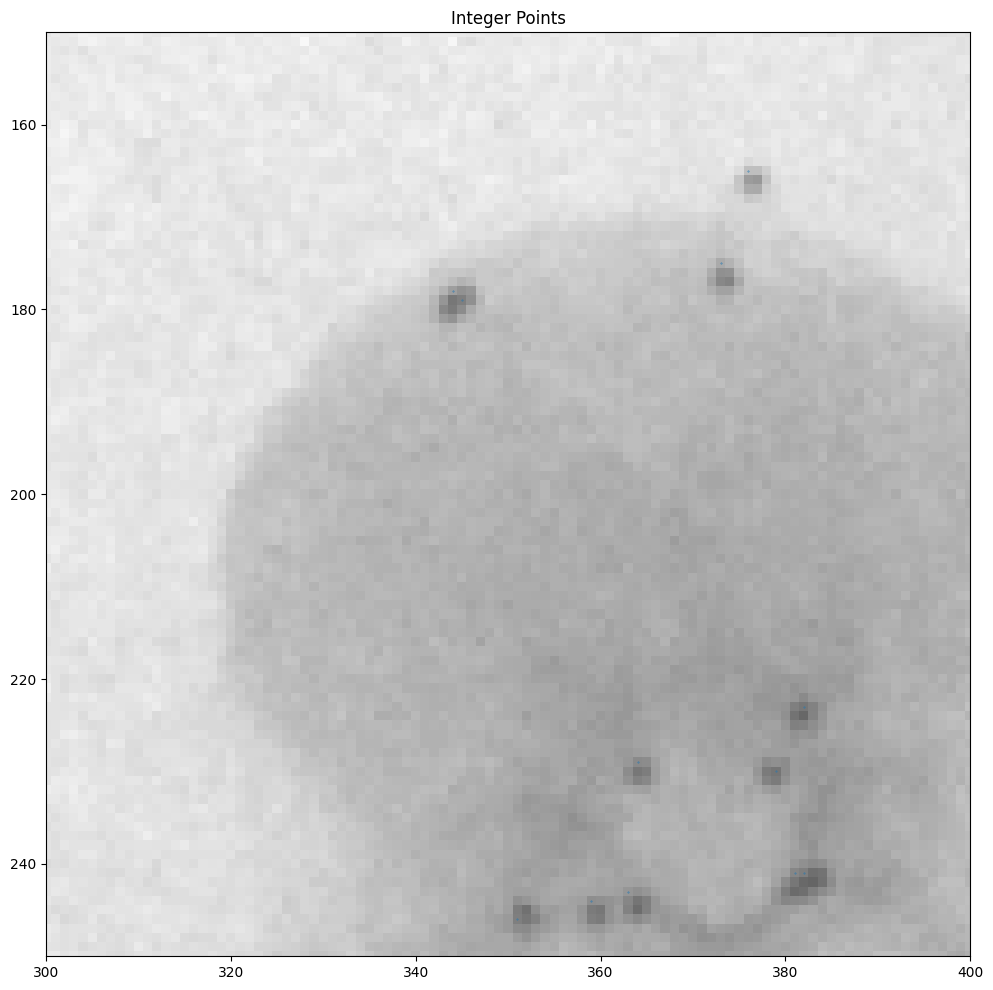

,frame_id,bodypart,camera,x_true,y_true,x_int,y_int,x_new,y_new
0,1,Cranium_Left_Anterior,cam1,373.809209,175.908624,373,175,370,173
100,1,Cranium_Left_Middle,cam1,376.579220,165.826861,376,165,374,166
200,1,Cranium_Right_Middle,cam1,344.314883,178.370694,344,178,341,179
300,1,Cranium_Right_Posterior,cam1,345.032394,179.453399,345,179,342,179
400,1,Beak_Mandible_Left_Posterior,cam1,382.453326,223.815459,382,223,384,226
500,1,Beak_Mandibile_Left_Anterior,cam1,379.293548,230.163533,379,230,382,228
600,1,Beak_Mandible_Right_Anterior,cam1,364.661935,229.964623,364,229,364,232
700,1,Beak_Maxilla_Right_Anterior,cam1,363.838480,243.545939,363,243,365,241
800,1,Beak_Maxilla_Right_Posterior,cam1,359.002493,244.749833,359,244,360,241
900,1,Beak_Maxilla_Left_Anterior,cam1,381.736479,241.854550,381,241,381,244


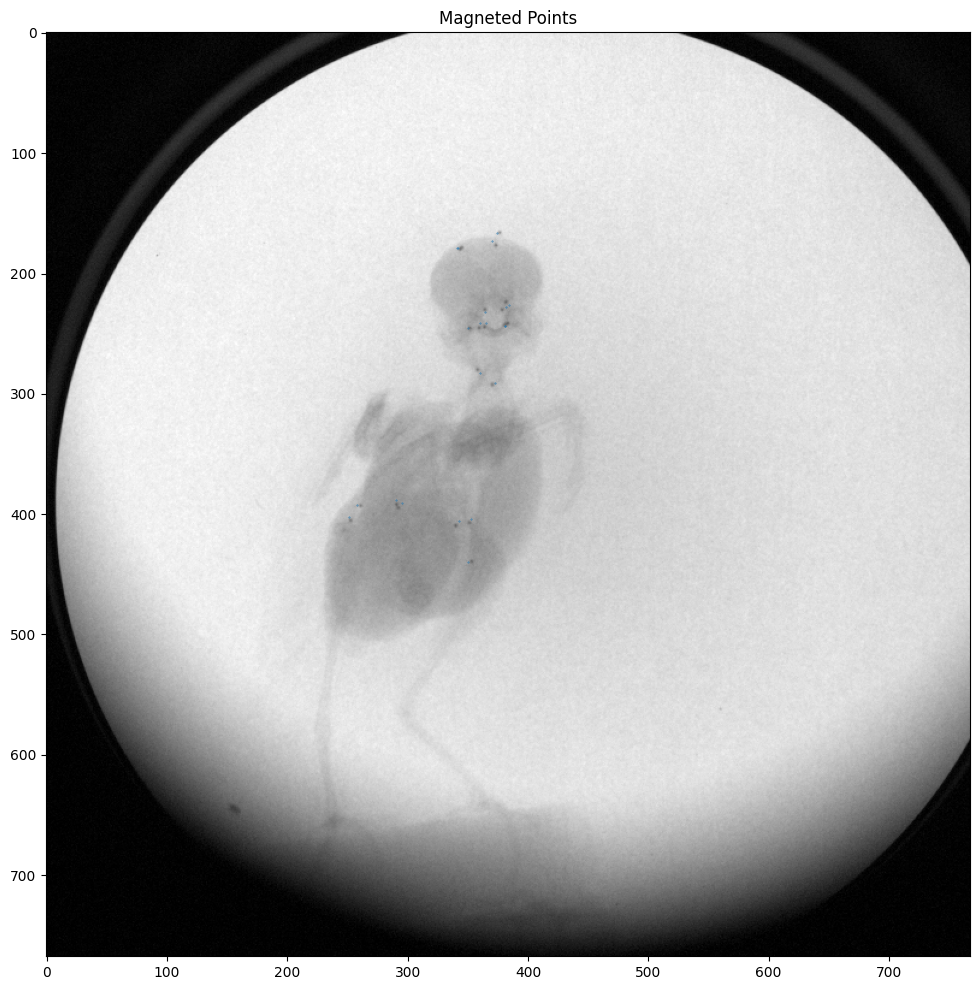

In [61]:
image = plt.imread(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DisplacementSamplesData\TrainT17_EvalT15\_build\Displacement_s125_TrainT17_EvalT15_F400_S42\clean_trial\Cam1\Cam1_Img002450.jpg")
data = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\SamplesForModelUpdate\DisplacementSamplesData\TrainT17_EvalT15\_build\Displacement_s125_TrainT17_EvalT15_F400_S42\clean_trial\Displacement_s125_TrainT17_EvalT15_F400_S42-2Dpoints.csv"
data_long = dlcs.truth_csv_to_long(data)
data_long = data_long[(data_long['camera'] == "cam1") & (data_long['frame_id'] == 1)]
plt.figure(figsize=(12, 12))
plt.imshow(image, cmap= 'grey')
plt.title('Image')
plt.show()
display(data_long)

plt.figure(figsize=(12, 12))
plt.imshow(image, cmap= 'grey')
plt.scatter(data_long['x_true'], data_long['y_true'], s = .11)
plt.title('Predicted Points')
plt.show()

plt.figure(figsize=(12, 12))
plt.imshow(image, cmap= 'grey')
data_long['x_int'] = data_long['x_true'].astype(int)
data_long['y_int'] = data_long['y_true'].astype(int)
plt.scatter(data_long['x_int'], data_long['y_int'], s = .11)
plt.ylim(250, 150)
plt.xlim(300, 400)
plt.title('Integer Points')
plt.show()

new_x = []
new_y = []
for index, row in data_long.iterrows():
    x = row['x_true']
    y = row['y_true']
    updated_point = find_darkest_region_center(image, x, y, search_radius=3)
    new_x.append(updated_point[0])
    new_y.append(updated_point[1])

data_long_magneted = data_long.copy()
data_long_magneted['x_new'] = new_x
data_long_magneted['y_new'] = new_y
display(data_long_magneted)
plt.figure(figsize=(12, 12))
plt.imshow(image, cmap= 'grey')
plt.scatter(data_long_magneted['x_new'], data_long_magneted['y_new'], s = .11)
plt.title('Magneted Points')
plt.show()